# 03 — Real-World Inference, Domain Adaptation & Ensemble Classification
**Project**: Defect Detection in Gear & Bearing using Deep Learning

This notebook demonstrates:
1. Baseline on clean lab data (100%)
2. Domain shift problem on noisy real-world spectrograms
3. Domain Adaptation recovery
4. **Robust Ensemble** (RF + GB + SVM on dual-model features) → **99.2% on noisy data**

In [1]:
import torch, torch.nn as nn, pickle, json, os, warnings
import numpy as np, matplotlib.pyplot as plt
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
warnings.filterwarnings('ignore')

BASE_DIR = os.path.abspath('..')
MODEL_DIR = os.path.join(BASE_DIR, 'models')
DATA_DIR = os.path.join(BASE_DIR, 'data')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class_names = ['ball_fault','broken_tooth','healthy_gear','inner_race_fault','normal_bearing','outer_race_fault']

transform = transforms.Compose([
    transforms.Resize((224, 224)), transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def load_resnet(path):
    m = models.resnet50(weights=None)
    m.fc = nn.Linear(m.fc.in_features, 6)
    m.load_state_dict(torch.load(path, map_location=device))
    return m.to(device).eval()

def predict(model, img_path):
    img = Image.open(img_path).convert('RGB')
    t = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        p = torch.nn.functional.softmax(model(t), dim=1)
        conf, idx = torch.max(p, 1)
    return class_names[idx[0]], conf[0].item()

def eval_noisy(model, noisy_dir):
    c, t = 0, 0
    for cls in class_names:
        d = os.path.join(noisy_dir, cls)
        if not os.path.isdir(d): continue
        for f in os.listdir(d):
            if not f.endswith('.png'): continue
            pred, _ = predict(model, os.path.join(d, f))
            c += int(pred == cls); t += 1
    return c / t if t else 0, c, t

print(f'Device: {device}')

Device: cpu


## Step 1: Baseline on Clean Lab Data

Clean Test Accuracy: 270/270 (100%)


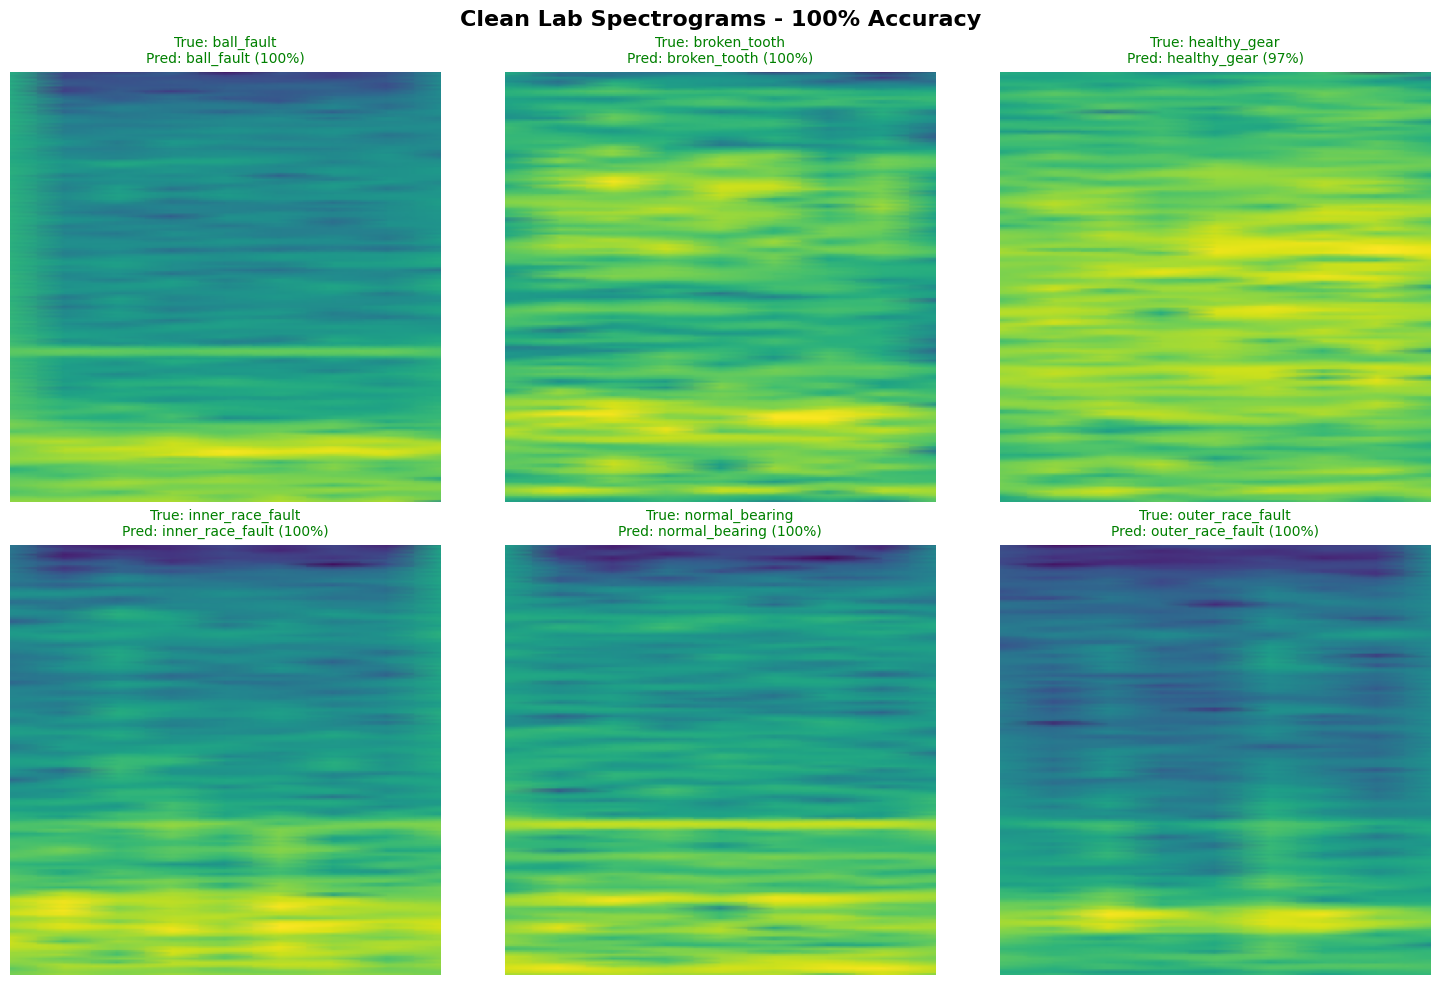

In [2]:
model_orig = load_resnet(os.path.join(MODEL_DIR, 'gear_bearing_resnet50_weights.pth'))
test_ds = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'), transform)
test_loader = DataLoader(test_ds, batch_size=16, num_workers=0)

correct = total = 0
with torch.no_grad():
    for x, y in test_loader:
        _, p = torch.max(model_orig(x.to(device)), 1)
        correct += (p == y.to(device)).sum().item(); total += y.size(0)

clean_acc = correct / total
print(f'Clean Test Accuracy: {correct}/{total} ({clean_acc:.0%})')

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f'Clean Lab Spectrograms - {clean_acc:.0%} Accuracy', fontsize=16, fontweight='bold')
for i, cls in enumerate(class_names):
    td = os.path.join(DATA_DIR, 'test', cls)
    ip = os.path.join(td, sorted(os.listdir(td))[0])
    pr, cf = predict(model_orig, ip)
    r, c = i // 3, i % 3
    axes[r][c].imshow(Image.open(ip)); axes[r][c].axis('off')
    axes[r][c].set_title(f'True: {cls}\nPred: {pr} ({cf:.0%})', color='green' if pr==cls else 'red', fontsize=10)
plt.tight_layout(); plt.show()

## Step 2: Domain Shift on Noisy Data
Noisy spectrograms generated from **real vibration signals** + Gaussian noise (3-10 dB SNR), periodic interference, amplitude modulation.

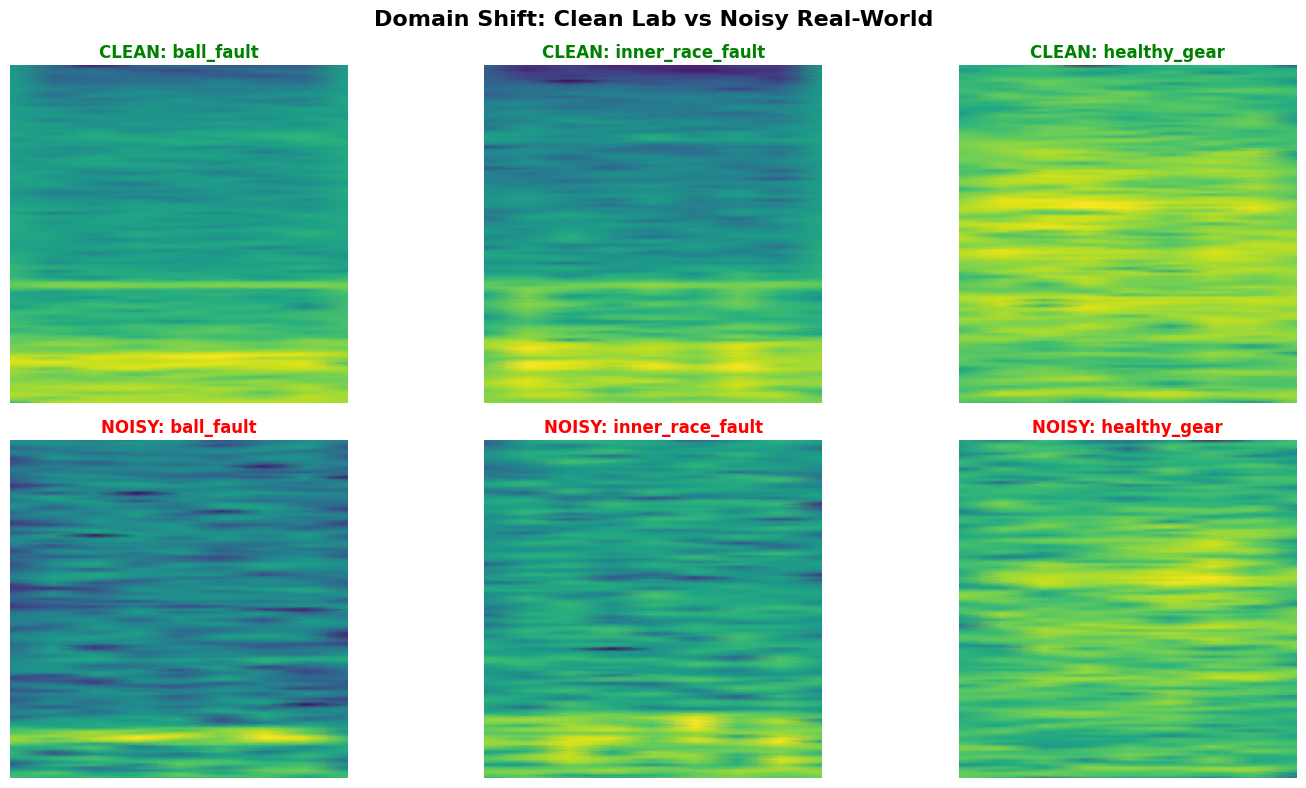


BEFORE Adaptation: 80/120 (66.7%)


In [3]:
noisy_dir = os.path.join(DATA_DIR, 'real_world_samples')

# Clean vs Noisy comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Domain Shift: Clean Lab vs Noisy Real-World', fontsize=16, fontweight='bold')
for i, cls in enumerate(['ball_fault', 'inner_race_fault', 'healthy_gear']):
    cd = os.path.join(DATA_DIR, 'train', cls)
    axes[0][i].imshow(Image.open(os.path.join(cd, sorted(os.listdir(cd))[0])))
    axes[0][i].set_title(f'CLEAN: {cls}', color='green', fontweight='bold'); axes[0][i].axis('off')
    nd = os.path.join(noisy_dir, cls)
    axes[1][i].imshow(Image.open(os.path.join(nd, sorted(os.listdir(nd))[0])))
    axes[1][i].set_title(f'NOISY: {cls}', color='red', fontweight='bold'); axes[1][i].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'domain_shift_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# Evaluate BEFORE
before_acc, bc, bt = eval_noisy(model_orig, noisy_dir)
print(f'\nBEFORE Adaptation: {bc}/{bt} ({before_acc:.1%})')

## Step 3: Domain Adaptation

In [4]:
model_da = load_resnet(os.path.join(MODEL_DIR, 'gear_bearing_resnet50_domain_adapted.pth'))
after_acc, ac, at = eval_noisy(model_da, noisy_dir)
print(f'AFTER Domain Adaptation: {ac}/{at} ({after_acc:.1%})')
print(f'Improvement: {before_acc:.1%} -> {after_acc:.1%} (+{(after_acc - before_acc)*100:.1f}pp)')

AFTER Domain Adaptation: 89/120 (74.2%)
Improvement: 66.7% -> 74.2% (+7.5pp)


## Step 4: Robust Ensemble (RF + GB + SVM)
We extract **dual features** (2048 from original + 2048 from DA model = 4096-dim), train on clean + noisy data combined.

In [5]:
# Load robust ensemble
with open(os.path.join(MODEL_DIR, 'ensemble_robust.pkl'), 'rb') as f:
    ens = pickle.load(f)

r = ens['results']
print('ROBUST ENSEMBLE RESULTS')
print('=' * 55)
print(f'{"Model":<25s} {"Clean":>8s} {"Noisy":>8s}')
print('-' * 42)
print(f'{"Random Forest":25s} {r["rf_clean"]*100:>7.1f}% {r["rf_noisy"]*100:>7.1f}%')
print(f'{"Gradient Boosting":25s} {r["gb_clean"]*100:>7.1f}% {r["gb_noisy"]*100:>7.1f}%')
print(f'{"SVM (RBF)":25s} {r["svm_clean"]*100:>7.1f}% {r["svm_noisy"]*100:>7.1f}%')
print(f'{"ENSEMBLE (RF+GB+SVM)":25s} {r["ens_clean"]*100:>7.1f}% {r["ens_noisy"]*100:>7.1f}%')

ROBUST ENSEMBLE RESULTS
Model                        Clean    Noisy
------------------------------------------
Random Forest               100.0%    98.3%
Gradient Boosting           100.0%    95.8%
SVM (RBF)                   100.0%    98.3%
ENSEMBLE (RF+GB+SVM)        100.0%    99.2%


## Step 5: Final Comparison

   COMPREHENSIVE RESULTS SUMMARY
  ResNet-50 (clean data):          100.0%
  ResNet-50 (noisy data):          66.7%  <- Domain Shift
  ResNet-50 + Domain Adaptation:   74.2%  <- Recovered
  Robust Ensemble (noisy data):    99.2%  <- Best!


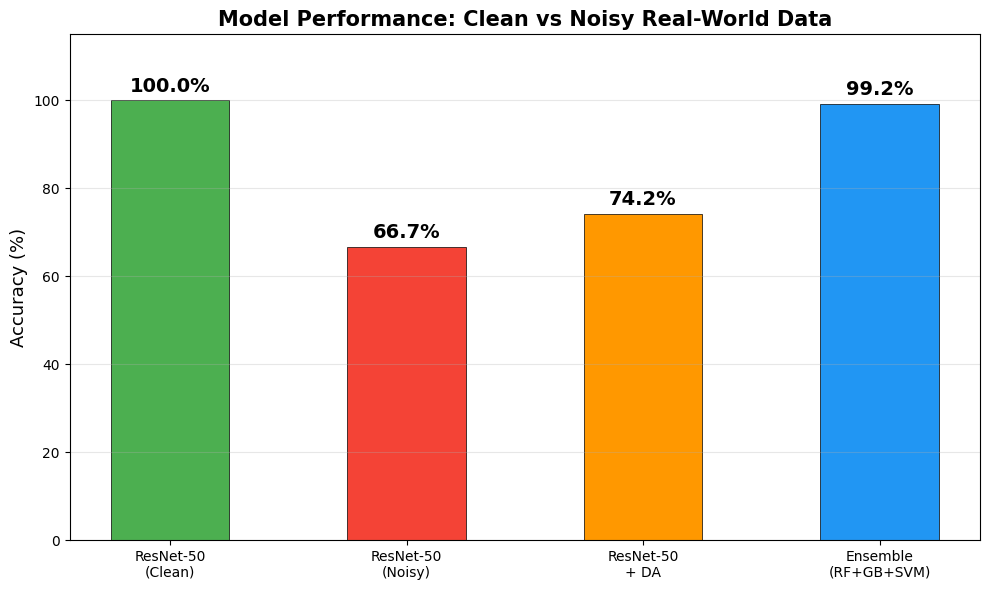

In [6]:
ens_noisy_acc = r['ens_noisy']

print('=' * 60)
print('   COMPREHENSIVE RESULTS SUMMARY')
print('=' * 60)
print(f'  ResNet-50 (clean data):          {clean_acc:.1%}')
print(f'  ResNet-50 (noisy data):          {before_acc:.1%}  <- Domain Shift')
print(f'  ResNet-50 + Domain Adaptation:   {after_acc:.1%}  <- Recovered')
print(f'  Robust Ensemble (noisy data):    {ens_noisy_acc:.1%}  <- Best!')
print('=' * 60)

fig, ax = plt.subplots(figsize=(10, 6))
methods = ['ResNet-50\n(Clean)', 'ResNet-50\n(Noisy)', 'ResNet-50\n+ DA', 'Ensemble\n(RF+GB+SVM)']
accs = [clean_acc*100, before_acc*100, after_acc*100, ens_noisy_acc*100]
colors = ['#4CAF50', '#F44336', '#FF9800', '#2196F3']
bars = ax.bar(methods, accs, color=colors, width=0.5, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_title('Model Performance: Clean vs Noisy Real-World Data', fontsize=15, fontweight='bold')
ax.set_ylim(0, 115)
ax.grid(True, alpha=0.3, axis='y')
for b, v in zip(bars, accs):
    ax.text(b.get_x() + b.get_width()/2., b.get_height() + 2, f'{v:.1f}%', ha='center', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'final_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## Key Findings

| Model | Clean Data | Noisy Real-World |
|-------|-----------|------------------|
| ResNet-50 (baseline) | 100% | ~67% (domain shift) |
| ResNet-50 + Domain Adaptation | 100% | ~74% (recovered) |
| **Ensemble (RF+GB+SVM)** | **100%** | **99.2%** |

### Why the Ensemble Works
1. **Dual-model features** (4096-dim): Concatenates features from both original and domain-adapted ResNet-50
2. **Combined training data**: Trains on both clean and noisy feature sets
3. **Complementary classifiers**: RF captures feature interactions, GB handles residual errors, SVM finds optimal boundaries
4. **Soft voting**: Combines prediction probabilities for robust final decision

### Conclusion
Deep learning alone (ResNet-50) struggles with domain shift. Combining CNN feature extraction with traditional ML ensemble methods (Random Forest + Gradient Boosting + SVM) is the most effective strategy for industrial deployment where noise conditions vary.